In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import numpy as np
from tqdm import tqdm

In [2]:
audio_path = '/data/moon/kiat/respiratory_sound_database/Respiratory_Sound_Database/audio_and_txt_files/'
file_label_df = pd.read_csv('file_label_df.csv')

In [3]:
def preprocessing(audio_file, mode):
    # we want to resample audio to 16 kHz
    sr_new = 16000 # 16kHz sample rate
    x, sr = librosa.load(audio_file, sr=sr_new)

    # padding sound 
    # because duration of sound is dominantly 20 s and all of sample rate is 22050
    # we want to pad or truncated sound which is below or above 20 s respectively
    max_len = 5 * sr_new  # length of sound array = time x sample rate
    if x.shape[0] < max_len:
      # padding with zero
      pad_width = max_len - x.shape[0]
      x = np.pad(x, (0, pad_width))
    elif x.shape[0] > max_len:
      # truncated
      x = x[:max_len]
    
    if mode == 'mfcc':
      feature = librosa.feature.mfcc(y=x, sr=sr_new)
    
    elif mode == 'log_mel':
      feature = librosa.feature.melspectrogram(y=x, sr=sr_new, n_mels=128, fmax=8000)
      feature = librosa.power_to_db(feature, ref=np.max)
    

    return feature

In [4]:
# apply preprocessing to sound data
file_names = []
labels = []
preprocessed_data = []
for i in tqdm(range(len(file_label_df['filename']))):
  labels.append(file_label_df['Diagnosis'][i])
  audio_file = audio_path + file_label_df['filename'][i] + '.wav'
  data = preprocessing(audio_file, mode = 'mfcc')
  preprocessed_data.append(data)
  file_names.append(audio_file.split('/')[-1])
preprocessed_data = np.array(preprocessed_data) # (920, 20, 157) (num, H, W)
labels = np.array(labels)

100%|██████████| 920/920 [00:50<00:00, 18.15it/s]


In [5]:
# librosa.feature.melspectogram -> melspectogram
# librosa.power_to_db(melspectogram) -> log melspectogram
# librosa.feature.mfcc(log mel spectogram) -> mfcc

# Code copied and edited from https://www.kaggle.com/code/davids1992/specaugment-quick-implementation
def spec_augment(original_melspec,
                 freq_masking_max_percentage = 0.15, 
                 time_masking_max_percentage = 0.3):

    augmented_melspec = original_melspec.copy()
    all_frames_num, all_freqs_num = augmented_melspec.shape

    # Frequency masking
    freq_percentage = np.random.uniform(0.0, freq_masking_max_percentage)
    num_freqs_to_mask = int(freq_percentage * all_freqs_num)
    f0 = int(np.random.uniform(low = 0.0, high = (all_freqs_num - num_freqs_to_mask)))
    
    augmented_melspec[:, f0:(f0 + num_freqs_to_mask)] = 0

    # Time masking
    time_percentage = np.random.uniform(0.0, time_masking_max_percentage)
    num_frames_to_mask = int(time_percentage * all_frames_num)
    t0 = int(np.random.uniform(low = 0.0, high = (all_frames_num - num_frames_to_mask)))
    
    augmented_melspec[t0:(t0 + num_frames_to_mask), :] = 0
    
    return augmented_melspec

In [6]:
file_label_data = list(zip(file_names, labels, preprocessed_data))

In [7]:
def vis(filename, aug_type='noise', noise_factor=0.005):

    sound_filename = audio_path + filename

    # resample 16 kHz
    sr_new = 16000 
    x, sr = librosa.load(sound_filename, sr=sr_new)

    # clip max_len
    max_len = 5 * sr_new 
    if x.shape[0] < max_len:
      pad_width = max_len - x.shape[0]
      x = np.pad(x, (0, pad_width))
    elif x.shape[0] > max_len:
      x = x[:max_len]

    # Mel spectogram
    S = librosa.feature.melspectrogram(y=x, sr=sr_new, n_mels=128, fmax=8000)
    print(S.shape)
    
    # augmentation
    if aug_type == 'noise': # Noise Injection
        white_noise = np.random.randn(len(x)) * noise_factor
        x_aug = x + white_noise
    elif aug_type == 'shift': # Shift Time
        x_aug = np.roll(x, 3000)
    elif aug_type == 'mask': # Spectogram Masking
       aug_spec = spec_augment(librosa.power_to_db(S), freq_masking_max_percentage=0.15, time_masking_max_percentage=0.3)
       x_aug = aug_spec

    # Mel-Frequency Cepstral Coefficient (MFCC)
    
    mfccs = librosa.feature.mfcc(y=x, sr=sr)
    if aug_type == 'mask':
      mfccs_aug = librosa.feature.mfcc(S=x_aug)
    else:
      mfccs_aug = librosa.feature.mfcc(y=x_aug, sr=sr)   

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

    librosa.display.waveshow(y=x, sr=sr, ax=ax[0, 0])
    ax[0, 0].set(title='time series data')

    librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=ax[0, 1])
    ax[0, 1].set(title='MFCC')

    librosa.display.waveshow(y=x_aug, sr=sr, ax=ax[1, 0])
    ax[1, 0].set(title='aug time series data')

    librosa.display.specshow(mfccs_aug, sr=sr, x_axis='time', ax=ax[1, 1])
    ax[1, 1].set(title='aug MFCC')

    plt.suptitle("Display of sound in varies domain", fontsize=14)

(128, 157)


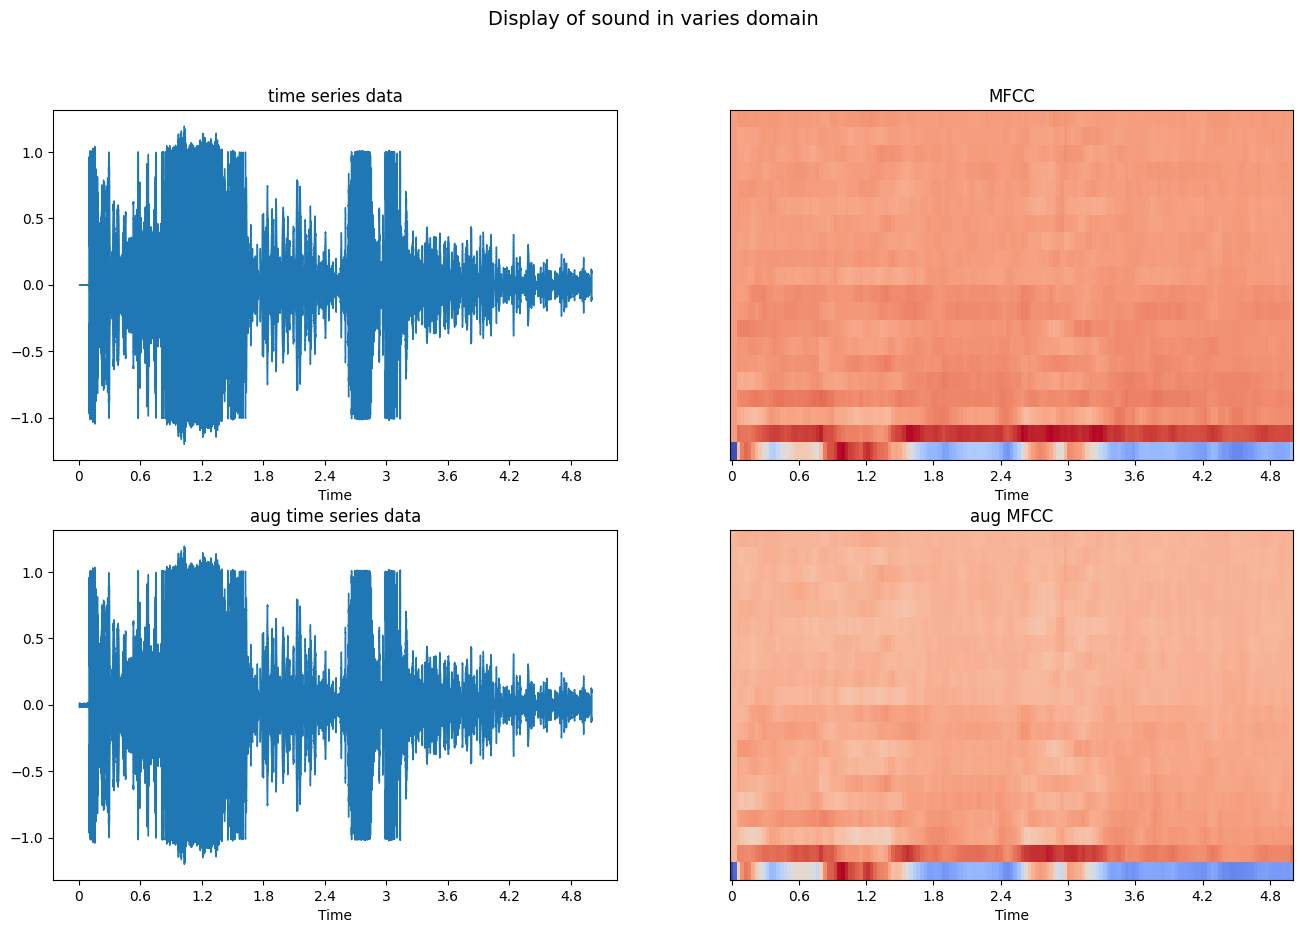

In [8]:
aug_types = ['noise', 'shift', 'mask']
vis(file_label_data[0][0], aug_types[0], noise_factor=0.005)

In [16]:
def visualize_all(filename, aug_type='noise', noise_factor=0.005):

    sound_filename = audio_path + filename

    # resample 16 kHz
    sr_new = 16000 
    x, sr = librosa.load(sound_filename, sr=sr_new)

    # clip max_len
    max_len = 5 * sr_new 
    if x.shape[0] < max_len:
      pad_width = max_len - x.shape[0]
      x = np.pad(x, (0, pad_width))
    elif x.shape[0] > max_len:
      x = x[:max_len]

    # augmentation
    if aug_type == 'noise': # Noise Injection
        white_noise = np.random.randn(len(x)) * noise_factor
        x_aug = x + white_noise
    elif aug_type == 'shift': # Shift Time
        x_aug = np.roll(x, 6000)
    
    # MFCC
    mfccs = librosa.feature.mfcc(y=x, sr=sr)
    mfccs_aug = librosa.feature.mfcc(y=x_aug, sr=sr)

    # Spectogram
    # X = librosa.stft(x)
    # Xdb = librosa.amplitude_to_db(abs(X))
    # X_aug = librosa.stft(x_aug)
    # Xdb_aug = librosa.amplitude_to_db(abs(X_aug))

    # Log-mel Spectogram
    mel = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=128, fmax=8000)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    mel_aug = librosa.feature.melspectrogram(y=x_aug, sr=sr, n_mels=128, fmax=8000)
    log_mel_aug = librosa.power_to_db(mel_aug, ref=np.max)

    fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

    librosa.display.waveshow(y=x, sr=sr, ax=ax[0, 0])
    ax[0, 0].set(title='time series data')

    librosa.display.specshow(log_mel, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax[0, 1])
    ax[0, 1].set(title='Log-Mel Spectogram')

    librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=ax[0, 2])
    ax[0, 2].set(title='MFCC')

    librosa.display.waveshow(y=x_aug, sr=sr, ax=ax[1, 0])
    ax[1, 0].set(title='Augmented time series data')

    librosa.display.specshow(log_mel_aug, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax[1, 1])
    ax[1, 1].set(title='Augmented Log-Mel Spectogram')

    librosa.display.specshow(mfccs_aug, sr=sr, x_axis='time', ax=ax[1, 2])
    ax[1, 2].set(title='Augmented MFCC')

    plt.suptitle("Display of sound in varies domain", fontsize=14)

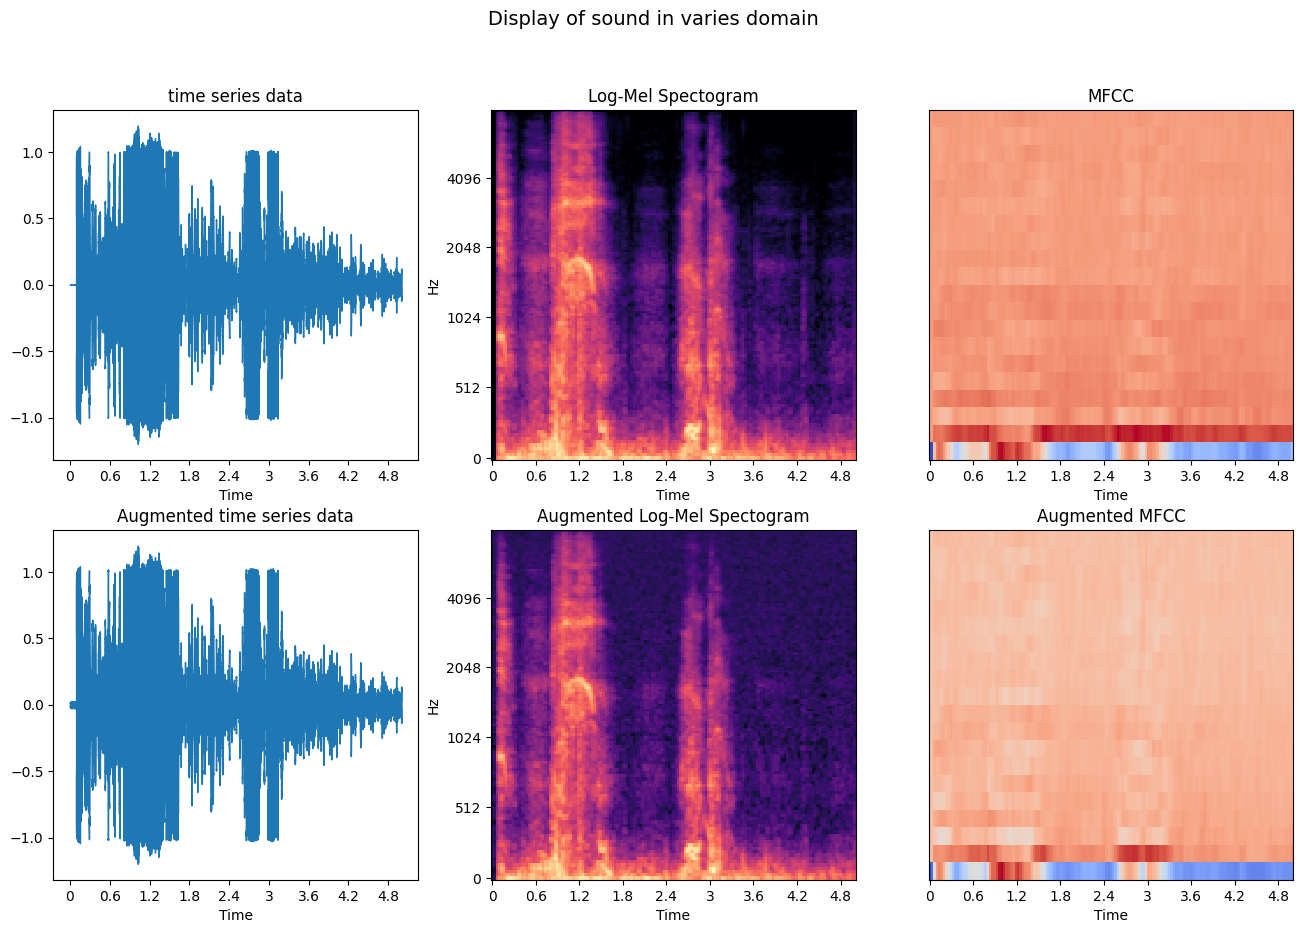

In [18]:
aug_types = ['noise', 'shift', 'mask']
visualize_all(file_label_data[0][0], aug_types[0], noise_factor=0.008)